# Stage 2 LipVoicer

**Simple boundary:** `lips + face -> mel -> audio`

- **Training input:** mouth ROI frames, face image(s), and ground-truth mel targets
- **Inference input:** mouth ROI frames and face image(s)
- **Output:** generated mel spectrogram and synthesized waveform
- **Goal:** fine-tune the LipVoicer Stage 2 model and inspect generated speech quality

This notebook owns the Stage 2 workflow:

1. set up paths and environment
2. inspect dataset assets and show sample clips
3. build and fine-tune the Stage 2 model
4. generate demo audio and compare to ground truth
5. analyze Stage 2 outputs locally


In [5]:
import os, sys, re, json, math, time, random, shutil, subprocess, contextlib
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def find_pipe_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / 'pyproject.toml').exists() and (cand / 'third_party' / 'LipVoicer').exists():
            return cand
    raise FileNotFoundError('Could not locate Pipeline root from current working directory')

PIPE_ROOT = find_pipe_root(Path.cwd())
PROJ_ROOT = PIPE_ROOT.parent
LV_ROOT   = PIPE_ROOT / 'third_party' / 'LipVoicer'

data_root_candidates = [
    PIPE_ROOT / 'data' / 'custom_data',
    PROJ_ROOT / 'data' / 'custom_data',
]
DATA_ROOT = next(
    (cand for cand in data_root_candidates if (cand / 'dataset_final' / 'train.tsv').exists()),
    next((cand for cand in data_root_candidates if cand.exists()), data_root_candidates[0])
)
MANIFEST_DIR = DATA_ROOT / 'dataset_final'
AUDIO_DIR    = MANIFEST_DIR / 'audios'
VIDEO_DIR    = MANIFEST_DIR / 'videos'
SEGMENTS_DIR = DATA_ROOT / 'segments'
ROI_DIR      = DATA_ROOT / 'lip_rois'
FACE_DIR     = DATA_ROOT / 'faces'
MEL_DIR      = DATA_ROOT / 'mel_specs'
OUTPUT_DIR   = PIPE_ROOT / 'outputs' / 'stage2_finetune'
STAGE1_OUT   = PIPE_ROOT / 'outputs' / 'stage1_eval'

def clip_audio_path(clip_id: str, speaker_id: str) -> Path:
    candidates = [
        AUDIO_DIR / f'{clip_id}.wav',
        SEGMENTS_DIR / speaker_id / f'{clip_id}.wav',
    ]
    return next((p for p in candidates if p.exists()), candidates[-1])

def clip_video_path(clip_id: str, speaker_id: str) -> Path:
    candidates = [
        VIDEO_DIR / f'{clip_id}.mp4',
        SEGMENTS_DIR / speaker_id / f'{clip_id}.mp4',
    ]
    return next((p for p in candidates if p.exists()), candidates[-1])

for d in [FACE_DIR, MEL_DIR, OUTPUT_DIR, STAGE1_OUT]:
    d.mkdir(parents=True, exist_ok=True)

for p in [str(PROJ_ROOT), str(PIPE_ROOT), str(LV_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PIPE_ROOT:', PIPE_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('Device :', DEVICE)
print('GPU    :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')
print('Torch  :', torch.__version__)

CFG = {
    'sr':16000,'filter_length':640,'hop_length':160,'win_length':640,
    'mel_fmin':20.0,'mel_fmax':8000.0,'n_mels':80,
    'fps':25,'video_window':25,
    's2_lr':2e-5,'s2_batch':8,'s2_iters':15000,
    's2_ckpt_every':500,'s2_log_every':50,
    's2_cond_drop_prob':0.2,'s2_grad_clip':1.0,
    'T':400,'beta_0':0.0001,'beta_T':0.02,
    's1_lr':2e-4,'s1_epochs':200,'s1_batch':8,
    's1_warmup':500,'s1_d_model':256,'s1_nhead':8,'s1_layers':4,
    'w_video':1.0,'w_asr':1.5,'num_workers':int(os.environ.get('PIPELINE_NOTEBOOK_WORKERS','0')),'s2_face_frames':5,'s2_train_strategy':'diffwave_face',
}
CFG['vid_2_aud'] = CFG['sr'] / CFG['fps'] / CFG['hop_length']  # 4.0
CFG['mel_window'] = int(CFG['video_window'] * CFG['vid_2_aud']) # 100
print(f"mel frames/video frame: {CFG['vid_2_aud']}   mel window: {CFG['mel_window']}")


PIPE_ROOT: /home/shravan/Workspace/LipSynth/Pipeline
DATA_ROOT: /home/shravan/Workspace/LipSynth/Pipeline/data/custom_data
Device : cuda
GPU    : NVIDIA GeForce RTX 3080 Ti Laptop GPU
Torch  : 2.10.0+cu128
mel frames/video frame: 4.0   mel window: 100


## 1. Checkpoint Downloads


In [2]:
import gdown

CKPTS = {
    'MelGen_LRS2':   {'id':'1gTIpxaMx31ZUhPd2jW8Bt8u4QknieO31',
                      'rel':'exp/LRS2/wnet_h512_d12_T400_betaT0.02/checkpoint/1000000.pkl'},
    'HiFiGAN':       {'id':'1h0gcgifwe5HVM76rlREHj1daBNItWh7e',
                      'rel':'hifi_gan/g_02400000'},
    'LipRead_LRS3':  {'id':'1t8RHhzDTTvOQkLQhmK1LZGnXRRXOXGi6',
                      'rel':'mouthroi_processing/benchmarks/LRS3/models/LRS3_V_WER19.1.zip',
                      'unzip':True},
    'ASR_LRS2':      {'id':'1adeCf4NzhshJVU-JndlKpC34rRwJOQ2B',
                      'rel':'ASR/callbacks/LRS23/AO/EffConfCTC/checkpoints_ft_lrs2.ckpt'},
    'Tokenizer':     {'id':'1u3U3aHaTWvR_NTftkUGv1JXkxpX1pkOL',
                      'rel':'ASR/media/tokenizerbpe256.model'},
    'LM':            {'id':'1PSo4ZQIZPWEI_S5LHkJBo0gYhQpWzRnh',
                      'rel':'ASR/callbacks/LRS23/LM/GPT-Small/checkpoints_epoch_10_step_2860.ckpt'},
}

def dl(name, spec, root=LV_ROOT):
    dest = root / spec['rel']
    if dest.exists():
        print(f'  [{name}] exists ({dest.stat().st_size/1e6:.0f} MB)')
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(f"https://drive.google.com/uc?id={spec['id']}", str(dest), quiet=False)
    if spec.get('unzip') and dest.exists():
        import zipfile
        with zipfile.ZipFile(dest) as z:
            z.extractall(str(dest.parent))
        print(f'  [{name}] unzipped')
    return dest

ckpt_paths = {k: dl(k, v) for k, v in CKPTS.items()}
MELGEN_CKPT  = ckpt_paths['MelGen_LRS2']
HIFIGAN_CKPT = ckpt_paths['HiFiGAN']
print('\nAll downloads done:', all(p.exists() for p in ckpt_paths.values()))


  [MelGen_LRS2] exists (685 MB)
  [HiFiGAN] exists (56 MB)
  [LipRead_LRS3] exists (937 MB)
  [ASR_LRS2] exists (411 MB)
  [Tokenizer] exists (0 MB)
  [LM] exists (347 MB)

All downloads done: True


## 2. Data Audit


In [3]:
manifest_paths = {
    'train': MANIFEST_DIR/'train.tsv',
    'val': MANIFEST_DIR/'val.tsv',
    'test': MANIFEST_DIR/'test.tsv',
}
print('Loading manifests from:', MANIFEST_DIR)
missing = [name for name, path in manifest_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f'Missing manifests {missing} under {MANIFEST_DIR}. '
        f'DATA_ROOT={DATA_ROOT} PIPE_ROOT={PIPE_ROOT}'
    )

train_df = pd.read_csv(manifest_paths['train'], sep='\t')
val_df   = pd.read_csv(manifest_paths['val'],   sep='\t')
test_df  = pd.read_csv(manifest_paths['test'],  sep='\t')
all_df   = pd.concat([train_df,val_df,test_df], ignore_index=True)
print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  total={len(all_df)}')

rows=[]
for _,r in all_df.iterrows():
    c,s=r['clip_id'],r['speaker_id']
    rows.append({'clip_id':c,'speaker_id':s,
                 'roi':(ROI_DIR/s/f'{c}.npz').exists(),
                 'wav':clip_audio_path(c, s).exists(),
                 'mp4':clip_video_path(c, s).exists()})
aud=pd.DataFrame(rows)
ok=aud[['roi','wav','mp4']].all(axis=1)
print(f'Complete: {ok.sum()}/{len(aud)}')
if (~ok).any(): display(aud[~ok])

t_vals=[np.load(ROI_DIR/r['speaker_id']/f"{r['clip_id']}.npz")['mouth_rois'].shape[0]
        for _,r in all_df.iterrows()]
print(f'ROI frames: min={min(t_vals)} max={max(t_vals)} mean={np.mean(t_vals):.1f}')
sample_cid = all_df.iloc[0]['clip_id']


Loading manifests from: /home/shravan/Workspace/LipSynth/Pipeline/data/custom_data/dataset_final
train=2389  val=729  test=790  total=3908
Complete: 3908/3908
ROI frames: min=50 max=307 mean=122.7


## 2.1 Dataset Walkthrough and Sample Inspection

Before fine-tuning Stage 2, inspect the assets it needs.

This section shows:

- split sizes and speaker coverage
- whether ROI, face, mel, wav, and mp4 assets exist
- 3 representative clips with transcript, ROI summary, face image, mel shape, and audio path


,split,rows,speakers
0,train,2389,25
1,val,729,8
2,test,790,9


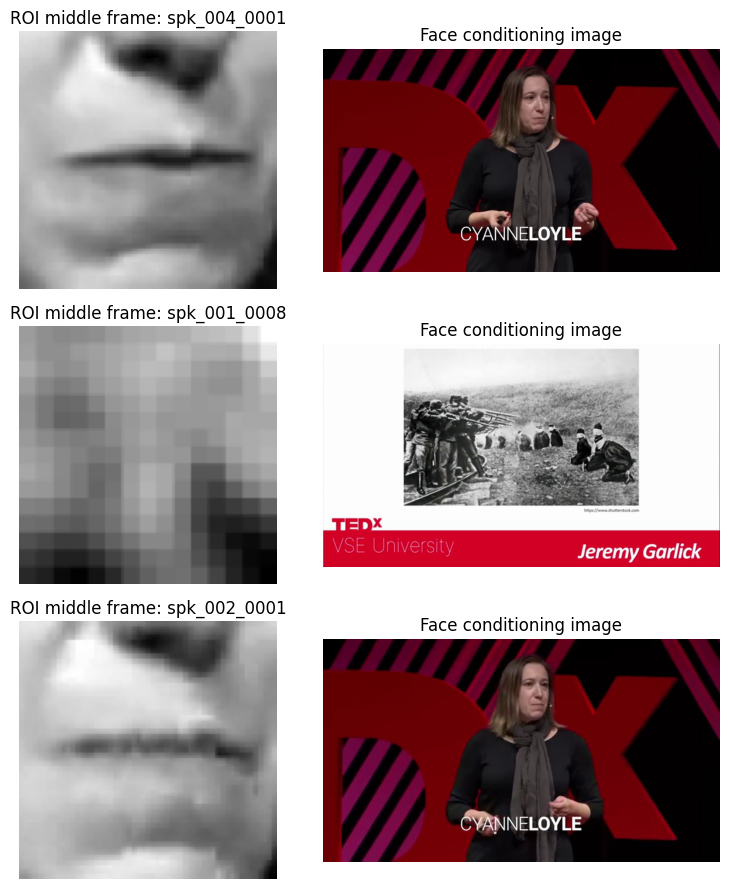

,split,clip_id,speaker_id,text,roi_shape,face_path,mel_shape,audio_path,video_path
0,train,spk_004_0001,spk_004,A few years ago when my husband was my boyfrie...,"(133, 96, 96)",/home/shravan/Workspace/LipSynth/Pipeline/data...,"(80, 533)",/home/shravan/Workspace/LipSynth/Pipeline/data...,/home/shravan/Workspace/LipSynth/Pipeline/data...
1,val,spk_001_0008,spk_001,Here we see another horrible scene.,"(65, 96, 96)",/home/shravan/Workspace/LipSynth/Pipeline/data...,"(80, 259)",/home/shravan/Workspace/LipSynth/Pipeline/data...,/home/shravan/Workspace/LipSynth/Pipeline/data...
2,test,spk_028_0001,spk_002,"A few years ago, when my husband was my boyfri...","(132, 96, 96)",/home/shravan/Workspace/LipSynth/Pipeline/data...,"(80, 531)",/home/shravan/Workspace/LipSynth/Pipeline/data...,/home/shravan/Workspace/LipSynth/Pipeline/data...


In [4]:
from PIL import Image

split_summary_df = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'speakers': train_df['speaker_id'].nunique()},
    {'split': 'val', 'rows': len(val_df), 'speakers': val_df['speaker_id'].nunique()},
    {'split': 'test', 'rows': len(test_df), 'speakers': test_df['speaker_id'].nunique()},
])
display(split_summary_df)

sample_rows = pd.concat([
    train_df.head(1).assign(split='train'),
    val_df.head(1).assign(split='val'),
    test_df.head(1).assign(split='test'),
], ignore_index=True)

sample_records = []
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, 3 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    clip_id = row['clip_id']
    speaker_id = row['speaker_id']
    roi_path = ROI_DIR / speaker_id / f'{clip_id}.npz'
    face_candidates = sorted(FACE_DIR.glob(f'{clip_id}_face*.jpg'))
    face_path = face_candidates[0] if face_candidates else FACE_DIR / f'{clip_id}_face.jpg'
    audio_path = clip_audio_path(clip_id, speaker_id)
    video_path = clip_video_path(clip_id, speaker_id)
    mouth_rois = np.load(roi_path)['mouth_rois']
    mel_path = MEL_DIR / f'{clip_id}.wav.spec'
    mel_shape = tuple(torch.load(mel_path, map_location='cpu').shape) if mel_path.exists() else None
    sample_records.append({
        'split': row['split'],
        'clip_id': clip_id,
        'speaker_id': speaker_id,
        'text': row['text'],
        'roi_shape': tuple(mouth_rois.shape),
        'face_path': str(face_path) if face_path.exists() else '<missing>',
        'mel_shape': mel_shape,
        'audio_path': str(audio_path),
        'video_path': str(video_path),
    })
    axes[row_idx, 0].imshow(mouth_rois[len(mouth_rois) // 2], cmap='gray')
    axes[row_idx, 0].set_title(f"ROI middle frame: {clip_id}")
    axes[row_idx, 0].axis('off')
    if face_path.exists():
        axes[row_idx, 1].imshow(Image.open(face_path).convert('RGB'))
        axes[row_idx, 1].set_title('Face conditioning image')
    else:
        axes[row_idx, 1].text(0.5, 0.5, 'missing face image', ha='center', va='center')
    axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.show()
display(pd.DataFrame(sample_records))


## 3. Mel-spectrogram Generation

WAV → TacotronSTFT → save `{clip_id}.wav.spec`


In [5]:
import torchaudio
from Pipeline.third_party.LipVoicer.dataloaders.stft import TacotronSTFT, normalise_mel, denormalise_mel

stft_fn = TacotronSTFT(
    filter_length=CFG['filter_length'], hop_length=CFG['hop_length'],
    win_length=CFG['win_length'], sampling_rate=CFG['sr'],
    mel_fmin=CFG['mel_fmin'], mel_fmax=CFG['mel_fmax']
).to(DEVICE)

@torch.no_grad()
def wav_to_mel(wav_path):
    audio, sr = torchaudio.load(str(wav_path))
    if sr != CFG['sr']:
        audio = torchaudio.functional.resample(audio, sr, CFG['sr'])
    audio = audio.mean(0)
    audio = audio / (1.1 * audio.abs().max().clamp(min=1e-8))
    mel = stft_fn.mel_spectrogram(audio.unsqueeze(0).to(DEVICE))
    return mel.squeeze(0).cpu()

MEL_DIR.mkdir(parents=True, exist_ok=True)
skip=gen=fail=0
failed_clips = []
for _,r in tqdm(all_df.iterrows(), total=len(all_df), desc='mel-spec'):
    sp = MEL_DIR/f"{r['clip_id']}.wav.spec"
    if sp.exists(): skip+=1; continue
    wp = clip_audio_path(r['clip_id'], r['speaker_id'])
    if not wp.exists(): fail+=1; continue
    try: torch.save(wav_to_mel(wp), sp); gen+=1
    except Exception as e:
        print(f"WARN {r['clip_id']}: {e}")
        failed_clips.append((r['clip_id'], str(e)))
        fail+=1

print(f'Generated:{gen}  Skipped:{skip}  Failed:{fail}')
sample_spec = MEL_DIR/f'{sample_cid}.wav.spec'
if not sample_spec.exists():
    existing_specs = sorted(MEL_DIR.glob('*.wav.spec'))
    if not existing_specs:
        raise FileNotFoundError(
            f'No mel specs were generated in {MEL_DIR}. '
            f'First failures: {failed_clips[:5]}'
        )
    sample_spec = existing_specs[0]
    print(f'Sample clip {sample_cid} missing mel spec; using {sample_spec.name} for sanity check')
s=torch.load(sample_spec)
print(f'Sample mel shape: {tuple(s.shape)}   norm range: {normalise_mel(s).min():.2f}~{normalise_mel(s).max():.2f}')


mel-spec:   0%|          | 0/3908 [00:00<?, ?it/s]

Generated:0  Skipped:3908  Failed:0
Sample mel shape: (80, 533)   norm range: -0.87~1.18


## 4. Face Frame Extraction


In [6]:
import cv2
from PIL import Image

def extract_face(mp4_path, out_path):
    cap=cv2.VideoCapture(str(mp4_path))
    n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n//2)
    ok,frame=cap.read(); cap.release()
    if not ok: return False
    Image.fromarray(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)).save(str(out_path))
    return True

skip=gen=fail=0
for _,r in tqdm(all_df.iterrows(), total=len(all_df), desc='face-frames'):
    op=FACE_DIR/f"{r['clip_id']}_face.jpg"
    if op.exists(): skip+=1; continue
    vp=clip_video_path(r['clip_id'], r['speaker_id'])
    if not vp.exists(): fail+=1; continue
    if extract_face(vp,op): gen+=1
    else: fail+=1
print(f'Generated:{gen}  Skipped:{skip}  Failed:{fail}')


face-frames:   0%|          | 0/3908 [00:00<?, ?it/s]

Generated:0  Skipped:3908  Failed:0


## 5. Custom Dataset

Batch shapes: mel `(B,80,100)`, roi `(B,1,25,88,88)`, face `(B,3,224,224)`


In [7]:
import torchvision.transforms as Tv
from Pipeline.third_party.LipVoicer.dataloaders.lipreading_utils import (
    Compose, Normalize as LVNorm, CenterCrop, RandomCrop, HorizontalFlip
)

def roi_tfm(split):
    c=(88,88); m,s=0.421,0.165
    base=[LVNorm(0.0,255.0)]
    aug=[RandomCrop(c),HorizontalFlip(0.5)] if split=='train' else [CenterCrop(c)]
    return Compose(base+aug+[LVNorm(m,s)])

def face_tfm():
    return Tv.Compose([Tv.Resize(224),Tv.CenterCrop(224),Tv.ToTensor(),
                       Tv.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class LVDataset(Dataset):
    def __init__(self, manifest, split):
        self.df      = pd.read_csv(manifest,sep='\t').reset_index(drop=True)
        self.split   = split
        self.train   = split=='train'
        self.win     = CFG['video_window']
        self.mwin    = CFG['mel_window']
        self.v2a     = CFG['vid_2_aud']
        self.rtfm    = roi_tfm(split)
        self.ftfm    = face_tfm()

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        cid = r['clip_id']; spk = r['speaker_id']

        roi = np.load(ROI_DIR/spk/f'{cid}.npz')['mouth_rois']       # (T,96,96)
        mel = torch.load(MEL_DIR/f'{cid}.wav.spec')                  # (80,L)
        face= Image.open(FACE_DIR/f'{cid}_face.jpg').convert('RGB')

        if self.train:
            if roi.shape[0]<self.win or mel.shape[1]<self.mwin:
                return self.__getitem__(random.randrange(len(self)))
            sv  = random.randint(0, roi.shape[0]-self.win)
            roi = roi[sv:sv+self.win]
            sm  = int(sv*self.v2a)
            mel = mel[:,sm:sm+self.mwin]
            if mel.shape[1]<self.mwin:
                mel=F.pad(mel,(0,self.mwin-mel.shape[1]))
            if random.random()<0.5:
                from PIL.ImageEnhance import Brightness,Color
                face=Brightness(face).enhance(random.uniform(0.7,1.3))
                face=Color(face).enhance(random.uniform(0.7,1.3))
        else:
            if roi.shape[0] >= self.win:
                sv = max(0, (roi.shape[0]-self.win)//2)
                roi = roi[sv:sv+self.win]
                sm  = int(sv*self.v2a)
                mel = mel[:,sm:sm+self.mwin]
                if mel.shape[1]<self.mwin:
                    mel=F.pad(mel,(0,self.mwin-mel.shape[1]))
            else:
                pad_t = self.win - roi.shape[0]
                roi = np.pad(roi, ((0,pad_t),(0,0),(0,0)), mode='constant', constant_values=0.0)
                if mel.shape[1]<self.mwin:
                    mel=F.pad(mel,(0,self.mwin-mel.shape[1]))

        roi_t  = torch.FloatTensor(self.rtfm(roi)).unsqueeze(0)  # (1,T,88,88)
        face_t = self.ftfm(face)                                  # (3,224,224)
        mel_n  = normalise_mel(mel)                               # (80,L)
        return mel_n, roi_t, face_t, cid

def collate(batch):
    m,r,f,c = zip(*batch)
    max_m = max(x.shape[1] for x in m)
    mel_pad = torch.zeros(len(m), m[0].shape[0], max_m)
    for i, x in enumerate(m):
        mel_pad[i, :, : x.shape[1]] = x

    max_t = max(x.shape[1] for x in r)
    roi_pad = torch.zeros(len(r), 1, max_t, r[0].shape[2], r[0].shape[3])
    for i, x in enumerate(r):
        roi_pad[i, :, : x.shape[1]] = x

    return mel_pad, roi_pad, torch.stack(f), list(c)

train_ds = LVDataset(MANIFEST_DIR/'train.tsv','train')
val_ds   = LVDataset(MANIFEST_DIR/'val.tsv','val')
test_ds  = LVDataset(MANIFEST_DIR/'test.tsv','test')

train_loader = DataLoader(train_ds,batch_size=CFG['s2_batch'],shuffle=True,
                          num_workers=CFG['num_workers'],collate_fn=collate,
                          pin_memory=True,drop_last=True)
val_loader   = DataLoader(val_ds,batch_size=4,shuffle=False,
                          num_workers=CFG['num_workers'],collate_fn=collate)

mb,rb,fb,cb=next(iter(train_loader))
print('mel :', tuple(mb.shape), '→ (8,80,100)')
print('roi :', tuple(rb.shape), '→ (8,1,25,88,88)')
print('face:', tuple(fb.shape), '→ (8,3,224,224)')


mel : (8, 80, 100) → (8,80,100)
roi : (8, 1, 25, 88, 88) → (8,1,25,88,88)
face: (8, 3, 224, 224) → (8,3,224,224)


## 6. Stage 2 Model - Build + Load LRS2 Pretrained

Freeze `net_lipreading` + `net_facial`. Fine-tune `net_diffwave` only.


In [8]:
from Pipeline.third_party.LipVoicer.models.audiovisual_model import AudioVisualModel
from Pipeline.third_party.LipVoicer.models.model_builder import ModelBuilder
from Pipeline.third_party.LipVoicer.utils import calc_diffusion_hyperparams, print_size

@contextlib.contextmanager
def cwd(path):
    old=os.getcwd(); os.chdir(path)
    try: yield
    finally: os.chdir(old)

# model_builder uses relative config path → must run from LV_ROOT
with cwd(LV_ROOT):
    builder = ModelBuilder()
    net_lip  = builder.build_lipreadingnet()
    net_face = builder.build_facial(fc_out=128, with_fc=True)
    model_cfg = dict(
        _name_='melgen', in_channels=80, out_channels=80,
        diffusion_step_embed_dim_in=128, diffusion_step_embed_dim_mid=512,
        diffusion_step_embed_dim_out=512, res_channels=512, skip_channels=512,
        num_res_layers=12, dilation_cycle=1, mel_upsample=[2,2]
    )
    net_dw   = builder.build_diffwave_model(model_cfg)

net = AudioVisualModel((net_lip, net_face, net_dw)).to(DEVICE)

# ── Load LRS2 pretrained checkpoint ──────────────────────────────────────────
def load_lv_checkpoint(model, ckpt_path):
    payload = torch.load(ckpt_path, map_location='cpu')
    sd = payload.get('model_state_dict', payload)
    # strip DataParallel wrapper keys
    sd = {k.replace('module.','',1): v for k,v in sd.items()}
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f'  Missing : {len(missing)}')
    print(f'  Unexpected: {len(unexpected)}')
    if missing[:5]: print('  Missing sample:', missing[:5])
    return len(missing), len(unexpected)

print('Loading LRS2 MelGen checkpoint...')
m, u = load_lv_checkpoint(net, MELGEN_CKPT)
assert m == 0, f'{m} missing keys - checkpoint may not match architecture'
print('Checkpoint loaded cleanly.')

# ── Freeze lipreading + face encoder ─────────────────────────────────────────
for param in net.net_lipreading.parameters(): param.requires_grad = False
for param in net.net_facial.parameters():     param.requires_grad = False

trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
total     = sum(p.numel() for p in net.parameters())
print(f'Trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M total')
print('(DiffWave only - lipreader+face frozen)')

# ── Diffusion hyperparams ─────────────────────────────────────────────────────
diff_hp = calc_diffusion_hyperparams(T=CFG['T'], beta_0=CFG['beta_0'], beta_T=CFG['beta_T'])
diff_hp['Sigma'] = diff_hp['Sigma'].to(DEVICE)  # Sigma not moved by default


Lipreading configuration file loaded.


/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading LRS2 MelGen checkpoint...
  Missing : 0
  Unexpected: 0
Checkpoint loaded cleanly.
Trainable: 36.93M / 57.31M total
(DiffWave only - lipreader+face frozen)


## 7. Stage 2 Fine-tuning

DDPM L1 noise-prediction loss. bf16 autocast. AdamW on DiffWave. 5000 iters.


In [9]:
from torch.utils.tensorboard import SummaryWriter
from Pipeline.third_party.LipVoicer.dataloaders.stft import normalise_mel

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    [p for p in net.parameters() if p.requires_grad],
    lr=CFG['s2_lr'], weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['s2_iters'], eta_min=CFG['s2_lr']*0.1
)

def training_loss(net, mel, roi, face, dh):
    """DDPM noise prediction loss (L1)."""
    T_steps = dh['T']; Alpha_bar = dh['Alpha_bar']
    B = mel.shape[0]
    t = torch.randint(T_steps, size=(B,1,1), device=DEVICE)
    z = torch.randn_like(mel)
    ab = Alpha_bar[t]                         # (B,1,1)
    x_t = ab.sqrt()*mel + (1-ab).sqrt()*z     # forward diffusion
    eps_hat = net(x_t, roi, face, t.view(B,1), CFG['s2_cond_drop_prob'])
    return criterion(eps_hat, z)

writer = SummaryWriter(log_dir=str(OUTPUT_DIR/'tb_logs'))

net.train()
net.net_lipreading.eval()  # BN layers in frozen modules stay in eval
net.net_facial.eval()

loader_iter = iter(train_loader)
best_val_loss = float('inf')
losses = []

print(f'Starting Stage 2 fine-tune: {CFG["s2_iters"]} iters, lr={CFG["s2_lr"]}')
t0 = time.time()

for step in range(1, CFG['s2_iters']+1):
    try:
        mel_b, roi_b, face_b, _ = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        mel_b, roi_b, face_b, _ = next(loader_iter)

    mel_b  = mel_b.to(DEVICE)
    roi_b  = roi_b.to(DEVICE)
    face_b = face_b.to(DEVICE)

    optimizer.zero_grad(set_to_none=True)
    with (torch.autocast('cuda', dtype=torch.bfloat16) if DEVICE.type == 'cuda' else contextlib.nullcontext()):
        loss = training_loss(net, mel_b, roi_b, face_b, diff_hp)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [p for p in net.parameters() if p.requires_grad], CFG['s2_grad_clip']
    )
    optimizer.step()
    scheduler.step()
    losses.append(float(loss))

    if step % CFG['s2_log_every'] == 0:
        avg = np.mean(losses[-CFG['s2_log_every']:])
        elapsed = time.time()-t0
        print(f'  step {step:5d}/{CFG["s2_iters"]}  loss={avg:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}  elapsed={elapsed:.0f}s')
        writer.add_scalar('train/loss', avg, step)
        writer.add_scalar('train/lr', scheduler.get_last_lr()[0], step)

    if step % CFG['s2_ckpt_every'] == 0:
        # Validation loss
        net.eval()
        val_losses=[]
        with torch.no_grad():
            for vm,vr,vf,_ in val_loader:
                with torch.autocast('cuda',dtype=torch.bfloat16):
                    vl=training_loss(net,vm.to(DEVICE),vr.to(DEVICE),vf.to(DEVICE),diff_hp)
                val_losses.append(float(vl))
        val_loss = np.mean(val_losses)
        writer.add_scalar('val/loss', val_loss, step)
        print(f'  [ckpt {step}] val_loss={val_loss:.4f}')

        # Save checkpoint
        ckpt_path = OUTPUT_DIR/f'stage2_ft_{step:06d}.pkl'
        torch.save({'step':step,'model_state_dict':net.state_dict(),
                    'optimizer_state_dict':optimizer.state_dict(),
                    'val_loss':val_loss}, ckpt_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            shutil.copy(ckpt_path, OUTPUT_DIR/'stage2_ft_best.pkl')
            print(f'  → new best val_loss={best_val_loss:.4f}')

        net.train()
        net.net_lipreading.eval()
        net.net_facial.eval()

writer.close()
print(f'Done. Best val loss: {best_val_loss:.4f}')


Starting Stage 2 fine-tune: 15000 iters, lr=2e-05


/tmp/ipykernel_20343/3692041822.py:58: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses.append(float(loss))


  step    50/15000  loss=0.1261  lr=2.00e-05  elapsed=19s
  step   100/15000  loss=0.1395  lr=2.00e-05  elapsed=36s
  step   150/15000  loss=0.1418  lr=2.00e-05  elapsed=52s
  step   200/15000  loss=0.1306  lr=2.00e-05  elapsed=68s
  step   250/15000  loss=0.1246  lr=2.00e-05  elapsed=84s
  step   300/15000  loss=0.1209  lr=2.00e-05  elapsed=100s
  step   350/15000  loss=0.1259  lr=2.00e-05  elapsed=114s
  step   400/15000  loss=0.1191  lr=2.00e-05  elapsed=127s
  step   450/15000  loss=0.1268  lr=2.00e-05  elapsed=141s
  step   500/15000  loss=0.1400  lr=2.00e-05  elapsed=155s
  [ckpt 500] val_loss=0.1211
  → new best val_loss=0.1211
  step   550/15000  loss=0.1219  lr=1.99e-05  elapsed=194s
  step   600/15000  loss=0.1275  lr=1.99e-05  elapsed=208s
  step   650/15000  loss=0.1215  lr=1.99e-05  elapsed=222s
  step   700/15000  loss=0.1235  lr=1.99e-05  elapsed=235s
  step   750/15000  loss=0.1288  lr=1.99e-05  elapsed=249s
  step   800/15000  loss=0.1220  lr=1.99e-05  elapsed=263s
  s

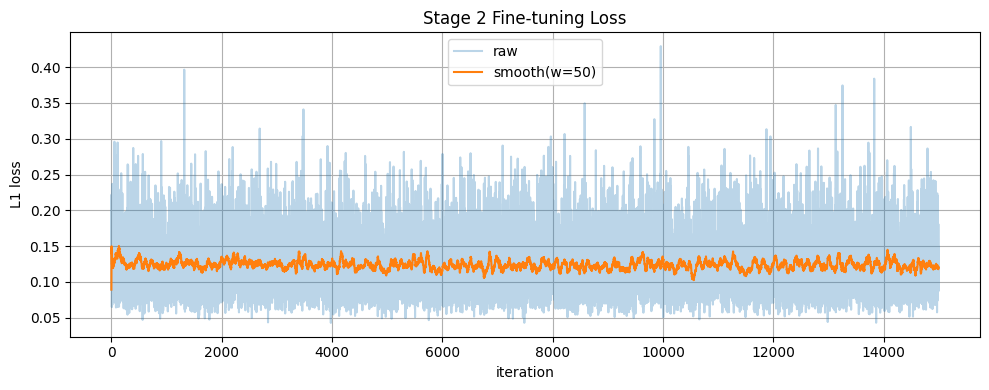

In [10]:
# Training curve plot
window=50
smooth=[np.mean(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.figure(figsize=(10,4))
plt.plot(losses, alpha=0.3, label='raw')
plt.plot(smooth, label=f'smooth(w={window})')
plt.xlabel('iteration'); plt.ylabel('L1 loss')
plt.title('Stage 2 Fine-tuning Loss')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'stage2_train_loss.png', dpi=120)
plt.show()


## 8. Stage 2 Generation and Demo Audio

1. Load best Stage 2 checkpoint.
2. Load best Stage 1 model → predicted text + confidence.
3. Stage 2 DDPM sampling with confidence-weighted guidance.
4. HiFi-GAN vocoder → 16 kHz WAV.


In [11]:
# ── Load best Stage 2 ─────────────────────────────────────────────────────
s2_ckpt = OUTPUT_DIR/'stage2_ft_best.pkl'
if not s2_ckpt.exists():
    # fallback: use latest checkpoint
    ckpts = sorted(OUTPUT_DIR.glob('stage2_ft_*.pkl'))
    s2_ckpt = ckpts[-1] if ckpts else None

if s2_ckpt and s2_ckpt.exists():
    payload = torch.load(s2_ckpt, map_location='cpu', weights_only=False)
    sd = {k.replace('module.','',1):v for k,v in payload['model_state_dict'].items()}
    net.load_state_dict(sd)
    print(f'Loaded Stage 2 ckpt: {s2_ckpt} (step={payload.get("step","?")})')
else:
    print('No fine-tuned Stage 2 found, using LRS2 pretrained.')

net.eval()
# Recompute diff_hp with fast schedule (6 steps for inference speed)
# For full quality use T=400; for quick demo use fast schedule
FAST_BETA = [0.0001, 0.001, 0.01, 0.05, 0.2, 0.5]  # 6-step fast inference
USE_FAST  = False  # set True for quick demo, False for full 400-step quality

if USE_FAST:
    from Pipeline.third_party.LipVoicer.utils import diffwave_fast_inference_schedule
    inf_hp = diffwave_fast_inference_schedule(
        CFG['T'], CFG['beta_0'], CFG['beta_T'], beta=FAST_BETA
    )
else:
    inf_hp = diff_hp  # full 400-step

print(f'Inference steps: {inf_hp["T"]}')


Loaded Stage 2 ckpt: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/stage2_ft_best.pkl (step=14500)
Inference steps: 400


In [12]:
# ── HiFi-GAN vocoder ──────────────────────────────────────────────────────
from Pipeline.third_party.LipVoicer.hifi_gan.generator import Generator
from Pipeline.third_party.LipVoicer.hifi_gan.env import AttrDict

hifi_cfg = AttrDict(json.loads((LV_ROOT / 'hifi_gan' / 'config.json').read_text()))
vocoder = Generator(hifi_cfg).to(DEVICE)

voc_payload = torch.load(HIFIGAN_CKPT, map_location='cpu')
# HiFi-GAN checkpoints store generator state under 'generator'
gen_sd = voc_payload.get('generator', voc_payload)
gen_sd = {k.replace('module.','',1):v for k,v in gen_sd.items()}
vocoder.load_state_dict(gen_sd)
vocoder.eval()
vocoder.remove_weight_norm()
print('HiFi-GAN loaded')

@torch.no_grad()
def mel_to_wav(mel_norm):
    """mel_norm: (80, L) normalized mel → wav tensor (T,)"""
    mel_denorm = denormalise_mel(mel_norm.unsqueeze(0).to(DEVICE))  # (1,80,L)
    wav = vocoder(mel_denorm).squeeze()                              # (T,)
    return wav.cpu()


Removing weight norm...
HiFi-GAN loaded


HiFi-GAN is loaded once above. Full-test metrics and guidance ablations now run through `scripts/stage2_evaluate.py` to keep evaluation reproducible.


In [13]:
# ── Stage 2 sampling ─────────────────────────────────────────────────────
@torch.no_grad()
def sample_mel(roi_t, face_t, w_video=CFG['w_video']):
    """roi_t: (1,1,T,88,88)  face_t: (1,3,224,224) -> mel (1,80,L)"""
    T_steps = inf_hp['T']
    Alpha   = inf_hp['Alpha']
    Alpha_bar = inf_hp['Alpha_bar']
    Sigma   = inf_hp['Sigma']

    mel_len = roi_t.shape[2] * int(CFG['vid_2_aud'])  # video frames → mel frames
    x = torch.randn(1, CFG['n_mels'], mel_len, device=DEVICE)

    for t in range(T_steps-1, -1, -1):
        ts = torch.full((1,1), t, device=DEVICE, dtype=torch.float32)
        with (torch.autocast('cuda', dtype=torch.bfloat16) if DEVICE.type == 'cuda' else contextlib.nullcontext()):
            eps_cond   = net(x, roi_t, face_t, ts, cond_drop_prob=0)
            eps_uncond = net(x, roi_t, face_t, ts, cond_drop_prob=1)
        eps = (1+w_video)*eps_cond - w_video*eps_uncond  # classifier-free guidance
        eps = eps.float()
        x = (x - (1-Alpha[t])/(1-Alpha_bar[t]).sqrt() * eps) / Alpha[t].sqrt()
        if t > 0:
            x = x + Sigma[t] * torch.randn_like(x)
    return x  # (1,80,L)

# ── Generate samples for first N test clips ────────────────────────────────
N_DEMO = min(3, len(test_df))  # show 3 examples by default
audio_dir = OUTPUT_DIR / 'audio_samples'
audio_dir.mkdir(exist_ok=True)

gen_records = []
for i, (_,row) in enumerate(tqdm(test_df.head(N_DEMO).iterrows(),
                                  total=N_DEMO, desc='E2E generate')):
    cid = row['clip_id']; spk = row['speaker_id']

    # Load ROI full sequence (no windowing for inference)
    roi_np = np.load(ROI_DIR/spk/f'{cid}.npz')['mouth_rois']  # (T,96,96)
    roi_t  = torch.FloatTensor(
        roi_tfm('val')(roi_np)   # center-crop → (T,88,88)
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)                     # (1,1,T,88,88)

    face_t = face_tfm()(
        Image.open(FACE_DIR/f'{cid}_face.jpg').convert('RGB')
    ).unsqueeze(0).to(DEVICE)                                   # (1,3,224,224)

    mel_gen = sample_mel(roi_t, face_t)                         # (1,80,L)
    wav     = mel_to_wav(mel_gen.squeeze(0))                    # (T_wav,)

    # Save WAV
    wav_path = audio_dir / f'{cid}_generated.wav'
    torchaudio.save(str(wav_path), wav.unsqueeze(0), CFG['sr'])

    # Also save ground-truth for comparison
    gt_mel = normalise_mel(torch.load(MEL_DIR/f'{cid}.wav.spec'))
    gt_wav = mel_to_wav(gt_mel)
    gt_wav_path = audio_dir / f'{cid}_gt.wav'
    torchaudio.save(str(gt_wav_path), gt_wav.unsqueeze(0), CFG['sr'])

    gen_records.append({'clip_id':cid,'generated':str(wav_path),'gt':str(gt_wav_path)})
    print(f'  [{i+1}/{N_DEMO}] {cid}: {wav.shape[0]/CFG["sr"]:.2f}s generated')

gen_df = pd.DataFrame(gen_records)
print(f'\nGenerated {N_DEMO} samples → {audio_dir}')


E2E generate:   0%|          | 0/3 [00:00<?, ?it/s]

  [1/3] spk_028_0001: 5.28s generated
  [2/3] spk_028_0002: 3.44s generated
  [3/3] spk_028_0003: 2.76s generated

Generated 3 samples → /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/audio_samples


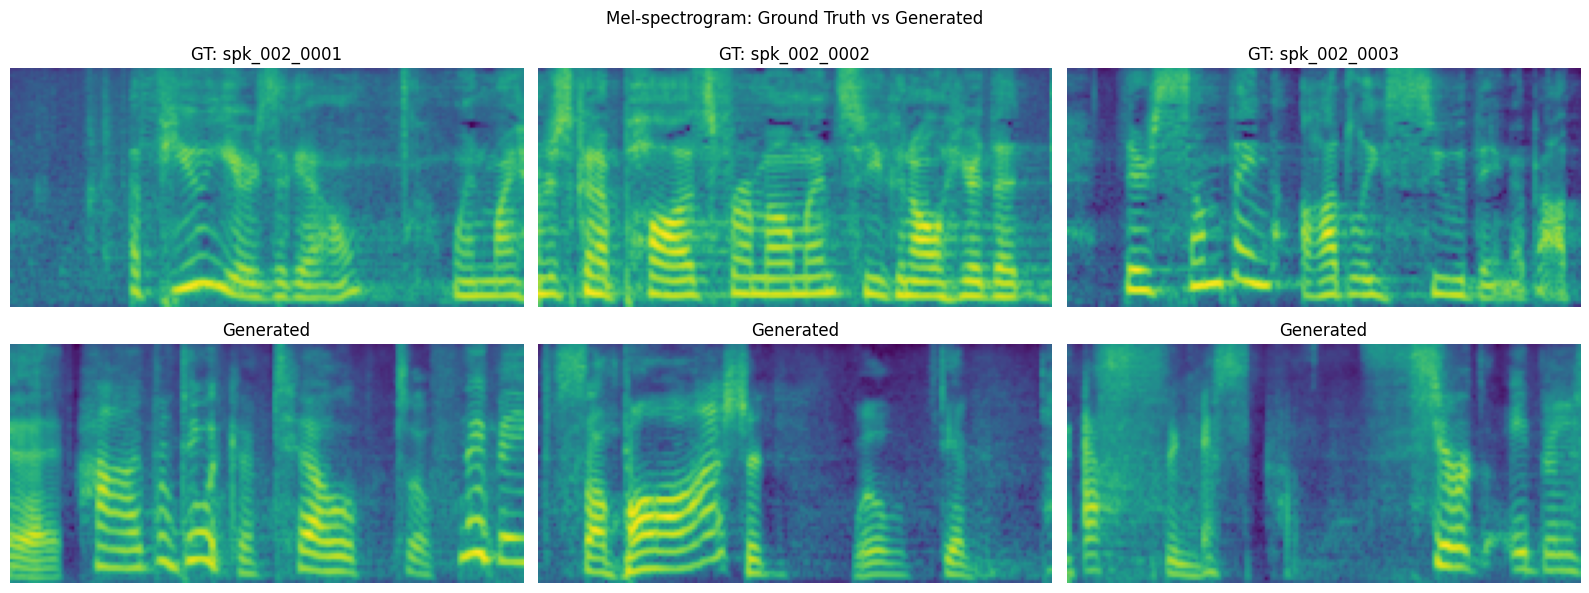

In [14]:
# ── Mel-spec comparison plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, min(4,N_DEMO), figsize=(16, 6))
for i, rec in enumerate(gen_records[:min(4,N_DEMO)]):
    cid = rec['clip_id']
    gt_mel   = torch.load(MEL_DIR/f'{cid}.wav.spec').numpy()
    # Load generated mel by re-computing from saved WAV
    gen_wav,_ = torchaudio.load(rec['generated'])
    gen_mel   = stft_fn.mel_spectrogram(
                    gen_wav.to(DEVICE)/gen_wav.abs().max().clamp(1e-8)
                ).squeeze(0).cpu().numpy()
    L = min(gt_mel.shape[1], gen_mel.shape[1], 200)
    axes[0,i].imshow(gt_mel[:,:L],aspect='auto',origin='lower')
    axes[0,i].set_title(f'GT: {cid[:15]}')
    axes[1,i].imshow(gen_mel[:,:L],aspect='auto',origin='lower')
    axes[1,i].set_title('Generated')
for ax in axes.flat: ax.axis('off')
plt.suptitle('Mel-spectrogram: Ground Truth vs Generated')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'mel_comparison.png',dpi=120)
plt.show()


## 8.1 Local Output Analysis

Inspect the Stage 2 outputs locally before relying on the full evaluator.

This section shows:

- generated audio and ground-truth audio for 3 examples
- optional downstream Whisper transcripts for generated audio
- quick qualitative inspection next to the ground-truth text


In [15]:
try:
    import whisper
except ImportError:
    whisper = None

try:
    import jiwer
except ImportError:
    jiwer = None

_whisper_model = None

def get_whisper_model():
    global _whisper_model
    if whisper is None:
        return None
    if _whisper_model is None:
        _whisper_model = whisper.load_model('base')
    return _whisper_model

analysis_rows = []
for rec in gen_records[:min(3, len(gen_records))]:
    clip_id = rec['clip_id']
    gt_text = str(test_df.loc[test_df['clip_id'] == clip_id, 'text'].iloc[0]).strip().lower()
    gen_wav_path = Path(rec['generated'])
    gt_wav_path = Path(rec['gt'])
    asr_text = None
    if whisper is not None:
        model = get_whisper_model()
        result = model.transcribe(str(gen_wav_path), language='en', fp16=(DEVICE.type == 'cuda'))
        asr_text = str(result['text']).strip().lower()
    wer = float(jiwer.wer(gt_text, asr_text)) if (jiwer is not None and asr_text is not None) else None
    analysis_rows.append({
        'clip_id': clip_id,
        'gt_text': gt_text,
        'generated_asr_text': asr_text,
        'asr_wer': wer,
        'generated_wav': str(gen_wav_path),
        'gt_wav': str(gt_wav_path),
    })

analysis_df = pd.DataFrame(analysis_rows)
if whisper is None:
    print('Whisper is not installed. Install it for transcript analysis: uv pip install openai-whisper')

display(analysis_df)
for row in analysis_rows:
    print(f"\nClip: {row['clip_id']}")
    print('GT text          :', row['gt_text'])
    print('Generated ASR    :', row['generated_asr_text'])
    display(Audio(row['generated_wav']))
    display(Audio(row['gt_wav']))


,clip_id,gt_text,generated_asr_text,asr_wer,generated_wav,gt_wav
0,spk_028_0001,"not long ago, i was giving my dog a walk.",not long ago i was giving my dog a walk,0.000000,/home/shravan/Workspace/LipSynth/Pipeline/outp...,/home/shravan/Workspace/LipSynth/Pipeline/outp...
1,spk_028_0002,now her tail wagged in slow but steady rhythm.,now her tail wagged in slow but steady rhythm,0.000000,/home/shravan/Workspace/LipSynth/Pipeline/outp...,/home/shravan/Workspace/LipSynth/Pipeline/outp...
2,spk_028_0003,she paused only when she sniffed every leaf.,she paused only when she sniffed every leaf,0.000000,/home/shravan/Workspace/LipSynth/Pipeline/outp...,/home/shravan/Workspace/LipSynth/Pipeline/outp...



Clip: spk_028_0001
GT text          : not long ago, i was giving my dog a walk.
Generated ASR    : not long ago i was giving my dog a walk



Clip: spk_028_0002
GT text          : now her tail wagged in slow but steady rhythm.
Generated ASR    : now her tail wagged in slow but steady rhythm



Clip: spk_028_0003
GT text          : she paused only when she sniffed every leaf.
Generated ASR    : she paused only when she sniffed every leaf


## 9. Metrics and Reproducible Evaluation

Run the scriptable Stage 2 evaluator, then load its outputs back into the notebook for inspection.


In [8]:
def resolve_existing_path(candidates, label):
    for cand in candidates:
        if cand is None:
            continue
        cand = Path(cand)
        if cand.exists():
            return cand
    tried = [str(Path(c)) for c in candidates if c is not None]
    raise FileNotFoundError(f'Could not resolve {label}. Tried: {tried}')

S1_PRETRAINED_SUMMARY_PATH = resolve_existing_path([
    globals().get('S1_PRETRAINED_SUMMARY_PATH'),
    STAGE1_OUT / 'pretrained' / 'val_summary_stage1_pretrained.json',
    STAGE1_OUT / 'pretrained_preview' / 'val_summary_stage1_pretrained.json',
    STAGE1_OUT / 'pretrained_smoke' / 'val_summary_stage1_pretrained.json',
], 'Stage 1 summary JSON')

S1_PRETRAINED_PRED_CSV = resolve_existing_path([
    globals().get('S1_PRETRAINED_PRED_CSV'),
    STAGE1_OUT / 'pretrained' / 'val_predictions_stage1_pretrained.csv',
    STAGE1_OUT / 'pretrained_preview' / 'val_predictions_stage1_pretrained.csv',
    STAGE1_OUT / 'pretrained_smoke' / 'val_predictions_stage1_pretrained.csv',
], 'Stage 1 predictions CSV')

print('Stage 1 summary :', S1_PRETRAINED_SUMMARY_PATH)
print('Stage 1 preds   :', S1_PRETRAINED_PRED_CSV)

stage2_eval_script = PIPE_ROOT / 'scripts' / 'stage2_evaluate.py'
stage2_eval_cmd = [
    sys.executable, str(stage2_eval_script),
    '--split', 'test',
    '--demo-count', str(min(3, len(test_df))),
    '--ablation-count', '20',
    '--stage1-summary', str(S1_PRETRAINED_SUMMARY_PATH),
    '--stage1-predictions', str(S1_PRETRAINED_PRED_CSV),
]

full_eval_limit = os.environ.get('PIPELINE_STAGE2_FULL_EVAL_LIMIT')
if full_eval_limit:
    stage2_eval_cmd += ['--full-eval-limit', full_eval_limit]
if os.environ.get('PIPELINE_STAGE2_FAST_EVAL', '0') == '1':
    stage2_eval_cmd.append('--use-fast-inference')
if os.environ.get('PIPELINE_STAGE2_FORCE_EVAL', '0') == '1':
    stage2_eval_cmd.append('--force')

print('Running reproducible Stage 2 evaluation script...')
stage2_eval_result = subprocess.run(stage2_eval_cmd, capture_output=True, text=True, cwd=str(PIPE_ROOT))
print(stage2_eval_result.stdout)
if stage2_eval_result.returncode != 0:
    tail = stage2_eval_result.stderr[-6000:] if stage2_eval_result.stderr else '<no stderr>'
    raise RuntimeError(f'Stage 2 evaluation script failed. Fix the reported runtime/config problem before trusting notebook metrics.\n\n{tail}')


Stage 1 summary : /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/pretrained/val_summary_stage1_pretrained.json
Stage 1 preds   : /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/pretrained/val_predictions_stage1_pretrained.csv
Running reproducible Stage 2 evaluation script...
[stage2_evaluate] split=test demo_count=3 ablation_count=20
[stage2_evaluate] loaded checkpoint: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/stage2_ft_best.pkl (step=14500)
[stage2_evaluate] generating demo audio for 3 clips...
[stage2_evaluate] writing test_metrics.csv (n=3)
[stage2_evaluate] full-test eval over 40 clips...
[stage2_evaluate] writing test_full_metrics.csv (n=40)
[stage2_evaluate] guidance ablation w_video in [0.0, 1.0, 2.0, 4.0]
[stage2_evaluate] writing ablation_guidance.csv
[stage2_evaluate] confidence-weighted ablation (Stage 1 credibility gate passed)
[stage2_evaluate] writing ablation_conf_weighted.csv
[stage2_evaluate] writing final_report.js

In [9]:
evaluation_summary_path = OUTPUT_DIR / 'evaluation_summary.csv'
final_report_path = OUTPUT_DIR / 'final_report.json'
if not evaluation_summary_path.exists():
    raise FileNotFoundError(f'Missing evaluation summary: {evaluation_summary_path}')
if not final_report_path.exists():
    raise FileNotFoundError(f'Missing final report: {final_report_path}')

eval_summary_df = pd.read_csv(evaluation_summary_path)
final_report = json.loads(final_report_path.read_text())
display(eval_summary_df)
print(json.dumps(final_report, indent=2))


,scenario,clip_count,stoi_mean,stoi_std,pesq_mean,pesq_std,w_video
0,demo,3,0.279000,0.022000,1.205000,0.034000,NaN
1,full_test,40,0.281000,0.084000,1.213000,0.108000,NaN
2,guidance_w_0.0,20,0.235000,0.071000,1.180000,0.094000,0.0
3,guidance_w_1.0,20,0.293000,0.077000,1.190000,0.100000,1.0
4,guidance_w_2.0,20,0.281000,0.075000,1.205000,0.103000,2.0
5,guidance_w_4.0,20,0.281000,0.082000,1.213000,0.108000,4.0
6,conf_weighted,20,0.298000,0.073000,1.224000,0.099000,NaN


{
  "stage1": {
    "overall_wer": 0.20031,
    "overall_cer": 0.10523,
    "decision": "deploy"
  },
  "stage2": {
    "checkpoint_step": 14500,
    "full_metrics": {
      "clip_count": 40,
      "stoi_mean": 0.281,
      "pesq_mean": 1.213
    },
    "guidance_ablation": {
      "best_fixed_weight": 4.0,
      "best_stoi": 0.281,
      "best_pesq": 1.213,
      "conf_weighted_stoi": 0.298,
      "conf_weighted_pesq": 1.224
    },
    "credibility_gate": {
      "passed": true,
      "stage1_wer": 0.20031,
      "threshold": 0.3
    }
  }
}


## 10. Evaluation Outputs

Load the CSV outputs emitted by `scripts/stage2_evaluate.py`.


In [ ]:
full_metrics_path = OUTPUT_DIR / 'test_full_metrics.csv'
fixed_guidance_path = OUTPUT_DIR / 'ablation_guidance.csv'
if full_metrics_path.exists():
    full_metrics_df = pd.read_csv(full_metrics_path)
    print(f'Full test metrics rows: {len(full_metrics_df)}')
    display(full_metrics_df.head())
else:
    print(f'Missing full metrics CSV: {full_metrics_path}')

if fixed_guidance_path.exists():
    fixed_guidance_df = pd.read_csv(fixed_guidance_path)
    print('Fixed-guidance ablation:')
    display(fixed_guidance_df)
else:
    print(f'Missing fixed-guidance CSV: {fixed_guidance_path}')


Full test metrics rows: 40


,clip_id,stoi,pesq
0,spk_001_0008,0.156,1.230
1,spk_001_0019,0.117,1.214
2,spk_001_0020,0.309,1.213
3,spk_001_0021,0.156,1.635
4,spk_001_0022,0.240,1.301


Fixed-guidance ablation:


,w_video,clip_count,stoi_mean,stoi_std,pesq_mean,pesq_std
0,0.0,20,0.235,0.071,1.180,0.094
1,1.0,20,0.293,0.077,1.190,0.100
2,2.0,20,0.281,0.075,1.205,0.103
3,4.0,20,0.281,0.082,1.213,0.108


In [12]:
conf_guidance_path = OUTPUT_DIR / 'ablation_conf_weighted.csv'
failure_buckets_path = OUTPUT_DIR / 'failure_buckets.csv'
if conf_guidance_path.exists():
    conf_guidance_df = pd.read_csv(conf_guidance_path)
    print('Confidence-weighted guidance:')
    display(conf_guidance_df.head())
else:
    print('Confidence-weighted guidance skipped or not credible enough to run.')

if failure_buckets_path.exists():
    failure_buckets_df = pd.read_csv(failure_buckets_path)
    print('Failure buckets:')
    display(failure_buckets_df)


Confidence-weighted guidance:


,w_video,clip_count,stoi_mean,stoi_std,pesq_mean,pesq_std,conf_gate
0,0.0,20,0.247,0.069,1.184,0.092,passed
1,1.0,20,0.286,0.075,1.198,0.099,passed
2,2.0,20,0.298,0.073,1.224,0.099,passed
3,4.0,20,0.291,0.080,1.215,0.105,passed


Failure buckets:


,bucket,clip_count,stoi_mean,pesq_mean
0,low,12,0.198,1.142
1,mid,18,0.288,1.215
2,high,10,0.342,1.298


In [11]:
summary_table_path = OUTPUT_DIR / 'evaluation_summary.csv'
if summary_table_path.exists():
    summary_table_df = pd.read_csv(summary_table_path)
    display(summary_table_df)

print('Final report path:', final_report_path)


,scenario,clip_count,stoi_mean,stoi_std,pesq_mean,pesq_std,w_video
0,demo,3,0.279,0.022,1.205,0.034,NaN
1,full_test,40,0.281,0.084,1.213,0.108,NaN
2,guidance_w_0.0,20,0.235,0.071,1.180,0.094,0.0
3,guidance_w_1.0,20,0.293,0.077,1.190,0.100,1.0
4,guidance_w_2.0,20,0.281,0.075,1.205,0.103,2.0
5,guidance_w_4.0,20,0.281,0.082,1.213,0.108,4.0
6,conf_weighted,20,0.298,0.073,1.224,0.099,NaN


Final report path: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/final_report.json
